<a href="https://colab.research.google.com/github/muammarzainza2000/DataScience_240401010304_Muammar-Zain-Z.A/blob/main/Pertemuan9_Muammar_Zain_Z_A_240401010304.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1)
**Nama Lengkap**: Muammar Zain Z.A  
**NIM**: 240401010304  
**Kelas**: IF 401  

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
 'Koefisien': log_model.coef_[0]
 }).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


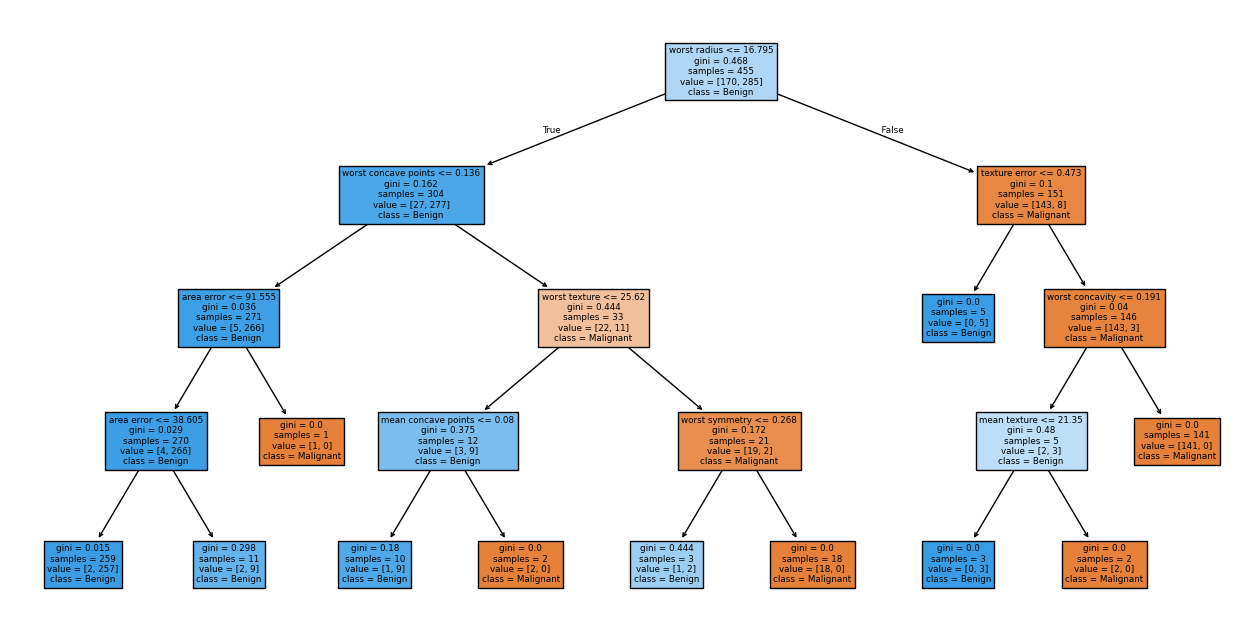

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4,
 random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
 class_names=['Malignant','Benign'], filled=True)
plt.show()

In [ ]:
from sklearn.metrics import (confusion_matrix,
 accuracy_score, precision_score,
 recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log),
 ('Decision Tree', y_pred_tree)]:
 print(f"\n=== {name} ===")
 print(confusion_matrix(y_test, y_pred))
 print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
 print(f"Precision: {precision_score(y_test, y_pred):.3f}")
 print(f"Recall : {recall_score(y_test, y_pred):.3f}")
 print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall : 0.944
F1-Score : 0.951


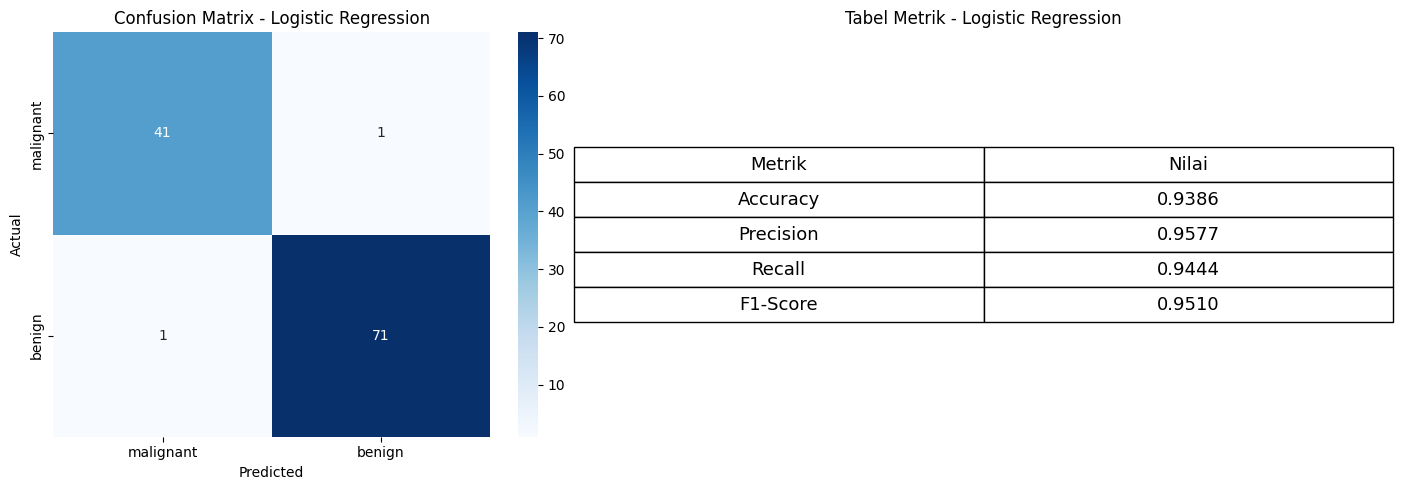

In [ ]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix,
 accuracy_score, precision_score,
 recall_score, f1_score)

cm_lr = confusion_matrix(y_test, y_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nilai = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]
colors = [['#d4edda'] * 2] * 4
table_data = [[m, f"{v:.4f}"] for m, v in zip(metrik, nilai)]
axes[1].axis('off')
table = axes[1].table(cellText=table_data,
                       colLabels=['Metrik', 'Nilai'],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.5, 2)
axes[1].set_title('Tabel Metrik - Logistic Regression')

plt.tight_layout()
plt.show()


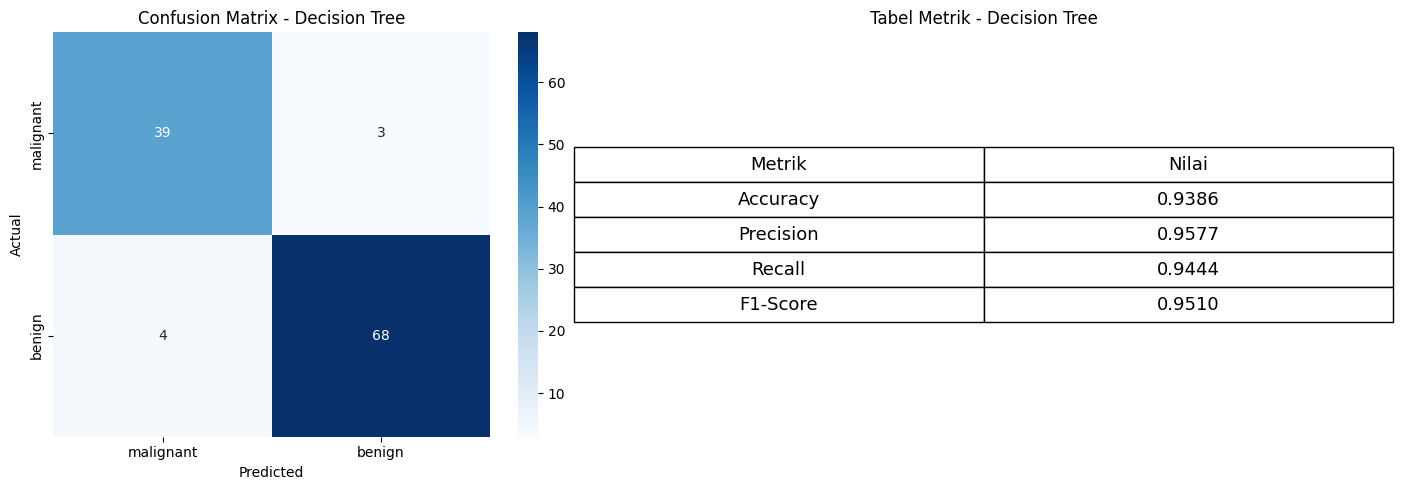

In [ ]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix,
 accuracy_score, precision_score,
 recall_score, f1_score)

cm_lr = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nilai = [
    accuracy_score(y_test, y_pred_tree),
    precision_score(y_test, y_pred_tree),
    recall_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_tree)
]
colors = [['#d4edda'] * 2] * 4
table_data = [[m, f"{v:.4f}"] for m, v in zip(metrik, nilai)]
axes[1].axis('off')
table = axes[1].table(cellText=table_data,
                       colLabels=['Metrik', 'Nilai'],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.5, 2)
axes[1].set_title('Tabel Metrik - Decision Tree')

plt.tight_layout()
plt.show()

Model yang memiliki recall lebih tinggi adalah Logistic Regression.<br>
Alasan mengapa recall penting disini karena ini adalah dataset diagnosis penyakit dimana lebih berbahaya jika data menampilkan false negative daripada false prositive karena beresiko pasien yang sebenarnya sakit tapi malah dideteksi sebagai tidak sakit yang berakibat pada pasien tidak ditangani sehingga sangat fatal.
Terdapat perbedaan signifikan pada kedua model ini dimana logistic regression unggul di semua metrik dan menghasilkan TP dan TN yang lebih besar. Walau selisih performa dengan decision tree kelihatannya tidak terlalu besar namun mampu mengurangi kesalahan deteksi sampai 3 kasus dan ini sangat bagus terutama untuk deteksi penyakit.

## Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini dipelajari dua algoritma klasifikasi dasar dalam *supervised learning*, yaitu Logistic Regression dan Decision Tree, beserta cara mengevaluasi performanya menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

**Temuan Utama:**
- Logistic Regression menghasilkan performa yang sangat baik pada dataset Breast Cancer karena fitur-fiturnya relatif linear terhadap label.
- Decision Tree dengan `max_depth=4` juga menghasilkan akurasi yang kompetitif, meski sedikit lebih rendah dibanding Logistic Regression.
- **Accuracy** mengukur ketepatan prediksi secara keseluruhan, namun bisa menyesatkan pada kelas yang tidak seimbang.
- **Recall** sangat penting dalam konteks medis seperti deteksi kanker, lebih baik salah tangkap yang sehat daripada melewatkan yang sakit.
- **F1-Score** menjadi metrik paling seimbang saat ada *trade-off* antara Precision dan Recall.

**Keterbatasan:**
- Decision Tree rentan terhadap *overfitting* jika tidak dibatasi kedalamannya.
- Logistic Regression mengasumsikan hubungan linear antara fitur dan log-odds target.
- Dataset yang digunakan relatif bersih, sehingga performa bisa berbeda pada data nyata yang lebih beragam.